# Framework 1: Fully Supervised
Multi-round AL on CIFAR-10 — train ResNet-18 from scratch on labelled subset each round.  
Reproduces paper's Figure 4a (top row).

**Matching paper (F.2.1):** ResNet-18, SGD (0.9 momentum, Nesterov), cosine LR, random crops + flips, weight re-init between rounds.  
**Limitations:** Paper uses 200 epochs with the Munjal et al. framework; we use 100 epochs due to computational constraints. Paper uses 10 reps; we use 3.

In [1]:
import sys, os, time, pickle
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from src.representations import load_encoder, extract_embeddings
from src.evaluation import run_al_rounds

In [2]:
RESULTS_FILE = './fw1_fully_supervised_results.pkl'
LOAD_SAVED = os.path.exists(RESULTS_FILE)

if not LOAD_SAVED:
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    trainloader = DataLoader(trainset, batch_size=256, shuffle=False, num_workers=2)
    testloader = DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

    encoder = load_encoder('./simclr_encoder_500ep.pth')
    embeddings, labels = extract_embeddings(encoder, trainloader)
    test_embeddings, test_labels = extract_embeddings(encoder, testloader)

    # Raw images for supervised training
    train_images = np.array([trainset[i][0].numpy() for i in range(len(trainset))])
    test_images = np.array([testset[i][0].numpy() for i in range(len(testset))])
    print(f"Embeddings: {embeddings.shape}, Images: {train_images.shape}")
else:
    print(f"Loading saved results from {RESULTS_FILE}")

Embeddings: (50000, 512), Images: (50000, 3, 32, 32)


In [3]:
if LOAD_SAVED:
    with open(RESULTS_FILE, 'rb') as f:
        results = pickle.load(f)
else:
    strategies = ['typiclust', 'random', 'uncertainty', 'margin', 'entropy', 'coreset', 'badge', 'bald', 'dbal']
    results = {}
    for s in strategies:
        t0 = time.time()
        print(f'Running {s}...', flush=True)
        results[s] = run_al_rounds(
            embeddings, labels, test_embeddings, test_labels,
            strategy=s, budget_per_round=10, n_rounds=5, n_reps=5,
            framework='fully_supervised',
            train_images=train_images, test_images=test_images
        )
        elapsed = time.time() - t0
        print(f'  {elapsed:.1f}s | mean={np.round(results[s]["mean"]*100, 1)}%')

    with open(RESULTS_FILE, 'wb') as f:
        pickle.dump(results, f)
    print('Results saved.')

Running typiclust...
  858.8s | mean=[12.9 19.1 20.3 22.3 24.6]%
Running random...
  247.1s | mean=[15.4 18.1 20.9 21.6 22.9]%
Running uncertainty...
  217.4s | mean=[19.2 18.1 18.7 20.9 19.5]%
Running margin...
  230.7s | mean=[18.2 18.8 19.3 21.9 21.2]%
Running entropy...
  239.9s | mean=[18.5 18.7 19.  17.7 19.3]%
Running coreset...
  271.5s | mean=[15.6 17.9 20.2 22.8 22.2]%
Running badge...
  1115.6s | mean=[18.5 20.5 19.7 22.6 23.2]%
Running bald...
  117.5s | mean=[18.2 18.8 18.6 18.4 18.9]%
Running dbal...
  118.0s | mean=[18.3 20.  20.2 20.  22. ]%
Results saved.


=== Fully Supervised (ResNet-18) ===
Strategy          B=10    B=20    B=30    B=40    B=50  
----------------------------------------------------------------------
typiclust          12.9%   19.1%   20.3%   22.3%   24.6%
random             15.4%   18.1%   20.9%   21.6%   22.9%
uncertainty        19.2%   18.1%   18.7%   20.9%   19.5%
margin             18.2%   18.8%   19.3%   21.9%   21.2%
entropy            18.5%   18.7%   19.0%   17.7%   19.3%
coreset            15.6%   17.9%   20.2%   22.8%   22.2%
badge              18.5%   20.5%   19.7%   22.6%   23.2%
bald               18.2%   18.8%   18.6%   18.4%   18.9%
dbal               18.3%   20.0%   20.2%   20.0%   22.0%


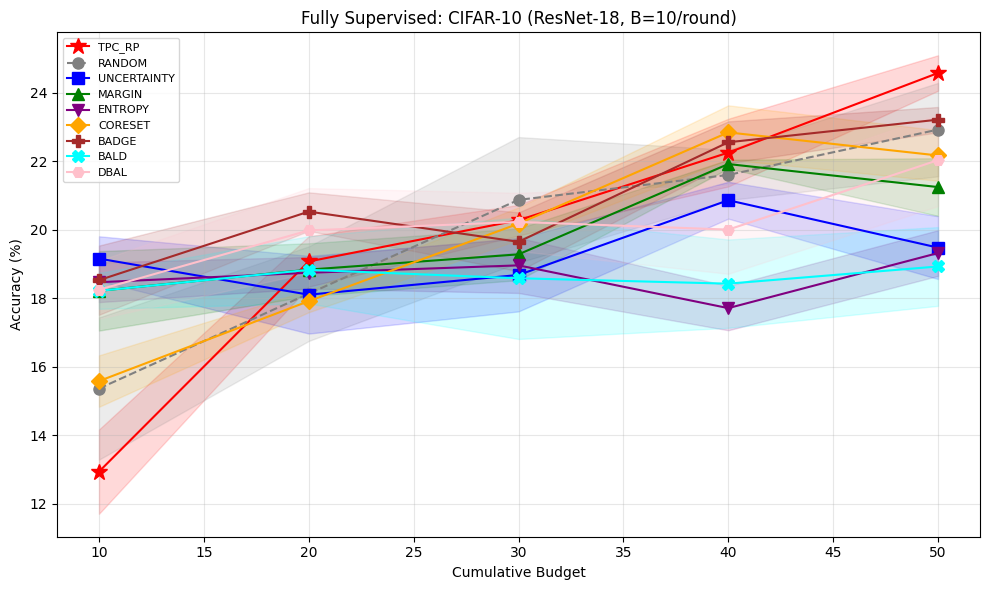

In [4]:
# Summary table
print("=== Fully Supervised (ResNet-18) ===")
print(f"{'Strategy':<15} ", end="")
for b in results['random']['budgets']:
    print(f"  B={b:<4}", end="")
print()
print("-" * 70)
for s in results:
    print(f"{s:<15} ", end="")
    for acc in results[s]['mean']:
        print(f"  {acc*100:5.1f}%", end="")
    print()

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
styles = {
    'random': {'color': 'gray', 'ls': '--', 'marker': 'o'},
    'uncertainty': {'color': 'blue', 'ls': '-', 'marker': 's'},
    'margin': {'color': 'green', 'ls': '-', 'marker': '^'},
    'entropy': {'color': 'purple', 'ls': '-', 'marker': 'v'},
    'coreset': {'color': 'orange', 'ls': '-', 'marker': 'D'},
    'badge': {'color': 'brown', 'ls': '-', 'marker': 'P'},
    'bald': {'color': 'cyan', 'ls': '-', 'marker': 'X'},
    'dbal': {'color': 'pink', 'ls': '-', 'marker': 'H'},
    'typiclust': {'color': 'red', 'ls': '-', 'marker': '*', 'markersize': 12},
}
for s, r in results.items():
    st = styles[s]
    label = 'TPC_RP' if s == 'typiclust' else s.upper()
    ax.plot(r['budgets'], r['mean']*100, label=label, color=st['color'],
            linestyle=st['ls'], marker=st['marker'], markersize=st.get('markersize', 8))
    if r['std'].max() > 0:
        ax.fill_between(r['budgets'], (r['mean']-r['std'])*100, (r['mean']+r['std'])*100,
                        alpha=0.15, color=st['color'])
ax.set_xlabel('Cumulative Budget')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Fully Supervised: CIFAR-10 (ResNet-18, B=10/round)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../report/figures/fw1_fully_supervised.png', dpi=300, bbox_inches='tight')
plt.show()